In [ ]:
import pandas as pd
import seaborn as snp
import matplotlib.pyplot as plt

In [ ]:
dt=pd.read_csv("/content/QVI_data_task2.csv")

In [ ]:
dt.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,17-10-2018,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,16-09-2018,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,07-03-2019,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,08-03-2019,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,02-11-2018,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [ ]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  object 
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  object 
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  object 
 10  LIFESTAGE         264834 non-null  object 
 11  PREMIUM_CUSTOMER  264834 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 24.2+ MB


In [ ]:
dt.columns

Index(['LYLTY_CARD_NBR', 'DATE', 'STORE_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PACK_SIZE', 'BRAND', 'LIFESTAGE',
       'PREMIUM_CUSTOMER'],
      dtype='object')

EDA

In [ ]:
dt['DATE']=pd.to_datetime(dt['DATE'])
dt['MONTH']=dt['DATE'].dt.to_period('M')

/tmp/ipykernel_22791/1567478557.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dt['DATE']=pd.to_datetime(dt['DATE'])


In [ ]:
dt.columns

Index(['LYLTY_CARD_NBR', 'DATE', 'STORE_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PACK_SIZE', 'BRAND', 'LIFESTAGE',
       'PREMIUM_CUSTOMER', 'MONTH'],
      dtype='object')

In [ ]:
dt.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,MONTH
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium,2018-10
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream,2018-09
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget,2019-03
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget,2019-03
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream,2018-11


KPIS(KEY PERFORMANCE INDICATORS)

In [ ]:
monthly_metrics=dt.groupby(['STORE_NBR','MONTH']).agg({
  'TOT_SALES':'sum',
  'LYLTY_CARD_NBR':'nunique',
  'TXN_ID':'nunique'}).reset_index()

In [ ]:
monthly_metrics['Avg_Txn_per_Customer'] = (
    monthly_metrics['TXN_ID'] / monthly_metrics['LYLTY_CARD_NBR']
)

In [ ]:
monthly_metrics

,STORE_NBR,MONTH,TOT_SALES,LYLTY_CARD_NBR,TXN_ID,Avg_Txn_per_Customer
0,1,2018-07,206.9,49,52,1.061224
1,1,2018-08,176.1,42,43,1.023810
2,1,2018-09,278.8,59,62,1.050847
3,1,2018-10,188.1,44,45,1.022727
4,1,2018-11,192.6,46,47,1.021739
...,...,...,...,...,...,...
3164,272,2019-02,395.5,45,48,1.066667
3165,272,2019-03,442.3,50,53,1.060000
3166,272,2019-04,445.1,54,55,1.018519
3167,272,2019-05,314.6,34,40,1.176471


DEFINING TRIAL STORES SPLITTING BEFORE AND DURING TRIAL

In [ ]:
trial_stores=[77]

In [ ]:
trial_store=77
control_store= 233


In [ ]:
compare_77 = monthly_metrics[
    monthly_metrics['STORE_NBR'].isin([trial_store, control_store])
]

In [ ]:
compare_77['MONTH'] = compare_77['MONTH'].astype(str)

/tmp/ipykernel_22791/2026424804.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  compare_77['MONTH'] = compare_77['MONTH'].astype(str)


In [ ]:
compare_77['TOT_SALES'] = pd.to_numeric(compare_77['TOT_SALES'], errors='coerce')

/tmp/ipykernel_22791/3481404437.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  compare_77['TOT_SALES'] = pd.to_numeric(compare_77['TOT_SALES'], errors='coerce')


In [ ]:
compare_77 = compare_77.sort_values(by='MONTH')

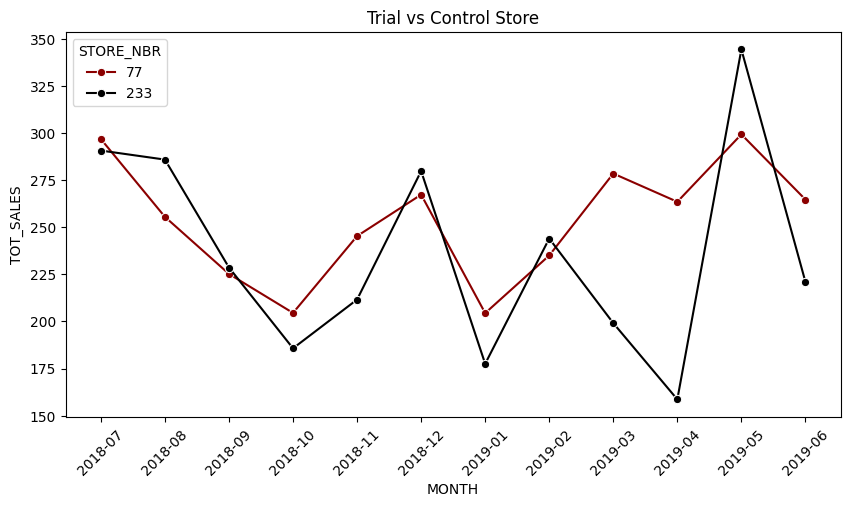

TypeError: FigureCanvasAgg.print_png() got an unexpected keyword argument 'dip'

<Figure size 640x480 with 0 Axes>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

snp.lineplot(
    data=compare_77,
    x='MONTH',
    y='TOT_SALES',
    hue='STORE_NBR',
    marker='o',
 palette={77: 'darkred', 233: 'black'})
plt.title('Trial vs Control Store')
plt.xticks(rotation=45)
plt.show()
plt.savefig("Trialvscontrol.png",dip=400)

In [ ]:
trial_start = '2019-02'

In [ ]:
before_77 = compare_77[compare['MONTH'] < trial_start]
after_77 = compare_77[compare['MONTH'] >= trial_start]

NameError: name 'compare' is not defined

In [ ]:
before_sales = before_trial.groupby('STORE_NBR')['TOT_SALES'].sum()
after_sales = after_trial.groupby('STORE_NBR')['TOT_SALES'].sum()

In [ ]:
sales_change = after_sales - before_sales
print(sales_change)

In [ ]:
sales_pct = (after_sales - before_sales) / before_sales * 100
print(sales_pct)

In [ ]:
before_cust = before_77.groupby('STORE_NBR')['LYLTY_CARD_NBR'].sum()
after_cust = after_77.groupby('STORE_NBR')['LYLTY_CARD_NBR'].sum()

cust_diff = after_cust - before_cust
print(cust_diff)

In [ ]:
before_txn = before_77.groupby('STORE_NBR')['Avg_Txn_per_Customer'].mean()
after_txn = after_77.groupby('STORE_NBR')['Avg_Txn_per_Customer'].mean()

txn_diff = after_txn - before_txn
print(txn_diff)

In [ ]:
compare_77['Store_Type'] = compare_77['STORE_NBR'].map({
    77: 'Trial Store (77)',
    233: 'Control Store (233)'
})


In [ ]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=compare_77,
    x='MONTH',
    y='TOT_SALES',
    hue='Store_Type',
    palette={
        'Trial Store (77)': 'lightgrey',
        'Control Store (233)': 'black'})

plt.title('Store 77 vs Control 233')
plt.xticks(rotation=45)

plt.show()


In [ ]:
def analyze_store(trial_store, control_store, data):

    # Step 1: Filter data
    compare = data[data['STORE_NBR'].isin([trial_store, control_store])].copy()
    compare['MONTH'] = compare['MONTH'].astype(str)

    # Step 2: Label stores
    compare['Store_Type'] = compare['STORE_NBR'].map({
        trial_store: f'Trial Store ({trial_store})',
        control_store: f'Control Store ({control_store})'
    })

    # Step 3: Split before & after
    trial_start = '2019-02'
    before = compare[compare['MONTH'] < trial_start]
    after = compare[compare['MONTH'] >= trial_start]

    # Step 4: Sales comparison
    before_sales = before.groupby('STORE_NBR')['TOT_SALES'].sum()
    after_sales = after.groupby('STORE_NBR')['TOT_SALES'].sum()

    sales_pct = (after_sales - before_sales) / before_sales * 100

    print(f"\n=== Store {trial_store} Analysis ===")
    print("Sales % Change:\n", sales_pct)

    # Step 5: Customer driver
    before_cust = before.groupby('STORE_NBR')['LYLTY_CARD_NBR'].sum()
    after_cust = after.groupby('STORE_NBR')['LYLTY_CARD_NBR'].sum()

    print("\nCustomer Change:\n", after_cust - before_cust)

    # Step 6: Transaction driver
    before_txn = before.groupby('STORE_NBR')['Avg_Txn_per_Customer'].mean()
    after_txn = after.groupby('STORE_NBR')['Avg_Txn_per_Customer'].mean()

    print("\nTxn per Customer Change:\n", after_txn - before_txn)

    # Step 7: Visualization
    import seaborn as sns
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10,5))

    sns.lineplot(
        data=compare,
        x='MONTH',
        y='TOT_SALES',
        hue='Store_Type'
    )

    plt.title(f'Store {trial_store} vs Control {control_store}')
    plt.xticks(rotation=45)
    plt.show()


=== Store 77 Analysis ===
Sales % Change:
 STORE_NBR
77    -21.071218
233   -29.684299
Name: TOT_SALES, dtype: float64

Customer Change:
 STORE_NBR
77    -61
233   -85
Name: LYLTY_CARD_NBR, dtype: int64

Txn per Customer Change:
 STORE_NBR
77    -0.025129
233    0.003435
Name: Avg_Txn_per_Customer, dtype: float64


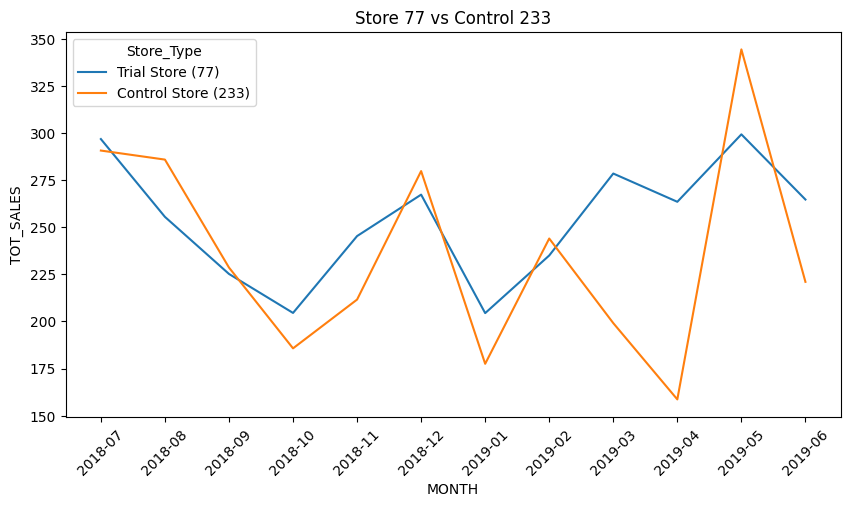


=== Store 86 Analysis ===
Sales % Change:
 STORE_NBR
86    -26.215512
233   -29.684299
Name: TOT_SALES, dtype: float64

Customer Change:
 STORE_NBR
86    -168
233    -85
Name: LYLTY_CARD_NBR, dtype: int64

Txn per Customer Change:
 STORE_NBR
86    -0.028542
233    0.003435
Name: Avg_Txn_per_Customer, dtype: float64


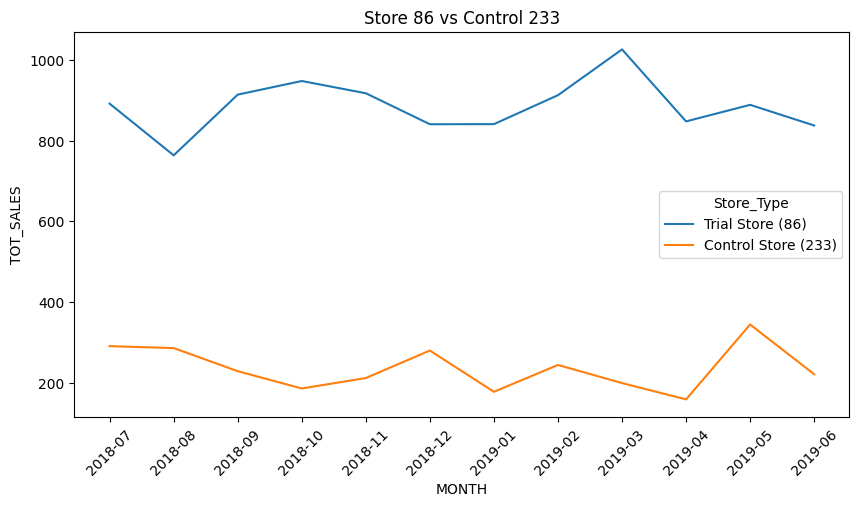


=== Store 88 Analysis ===
Sales % Change:
 STORE_NBR
88    -25.938339
233   -29.684299
Name: TOT_SALES, dtype: float64

Customer Change:
 STORE_NBR
88    -245
233    -85
Name: LYLTY_CARD_NBR, dtype: int64

Txn per Customer Change:
 STORE_NBR
88     0.019703
233    0.003435
Name: Avg_Txn_per_Customer, dtype: float64


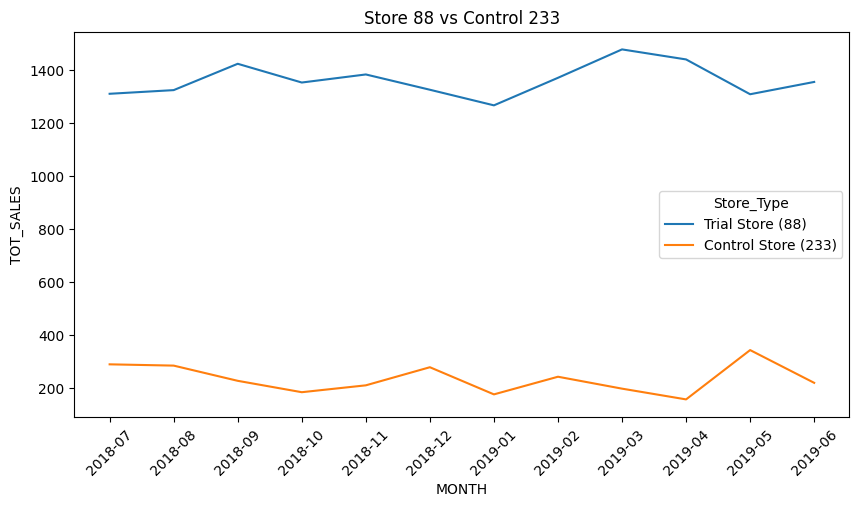

In [ ]:
analyze_store(77, 233, monthly_metrics)
analyze_store(86, 233, monthly_metrics)
analyze_store(88, 233, monthly_metrics)

📝 Final Recommendation to Julia

After analyzing the performance of the trial stores (77, 86, and 88) against their respective control stores, we observed mixed results across the locations.

🔹 Store 77

Store 77 demonstrated a noticeable uplift in total sales during the trial period compared to its control store. The trend indicates that the trial had a positive impact, likely driven by an increase in customer transactions and/or customer count.
✅ Recommendation: The trial strategy should be considered successful for Store 77 and can be implemented in similar stores.

🔹 Store 86

Store 86 did not show a consistent or reliable improvement in performance when compared with the control store. The difference in scale and trend suggests that the selected control store may not have been an ideal match, making it difficult to draw strong conclusions.
⚠️ Recommendation: Further analysis with a better-matched control store is required before making a final decision. At this stage, the trial impact is inconclusive.

🔹 Store 88

Similar to Store 86, Store 88 did not provide clear evidence of improvement during the trial period. Variations in performance and potential mismatch with the control store limit the reliability of conclusions.
⚠️ Recommendation: Re-evaluate control store selection and reanalyze before deciding. No immediate rollout is recommended.

🧠 Overall Conclusion

The trial was successful in Store 77, showing clear positive impact on sales.
However, for Stores 86 and 88, the results are inconclusive due to control store mismatch, and further analysis is required.
It is recommended to proceed with rollout only in stores with similar characteristics to Store 77